In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine('sqlite:///data/creditrisk.db')
df = pd.read_sql('SELECT * FROM german_credit', engine)

print(df.shape)
df.head()

(1000, 21)


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installments,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


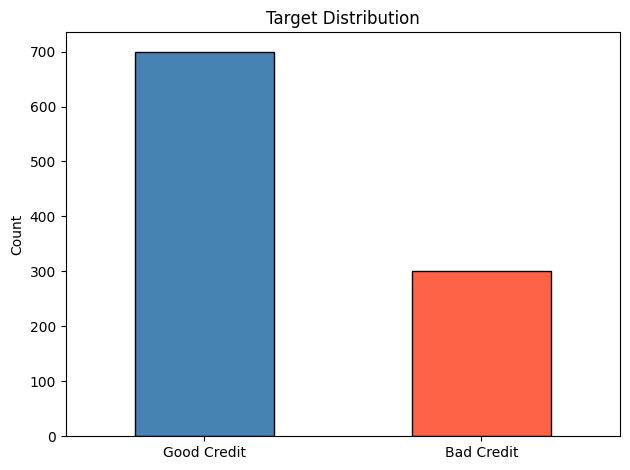

Good Credit    700
Bad Credit     300
Name: count, dtype: int64


In [3]:
import matplotlib.pyplot as plt

target_counts = df['target'].value_counts()
target_counts.index = ['Good Credit', 'Bad Credit']

target_counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Target Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(target_counts)

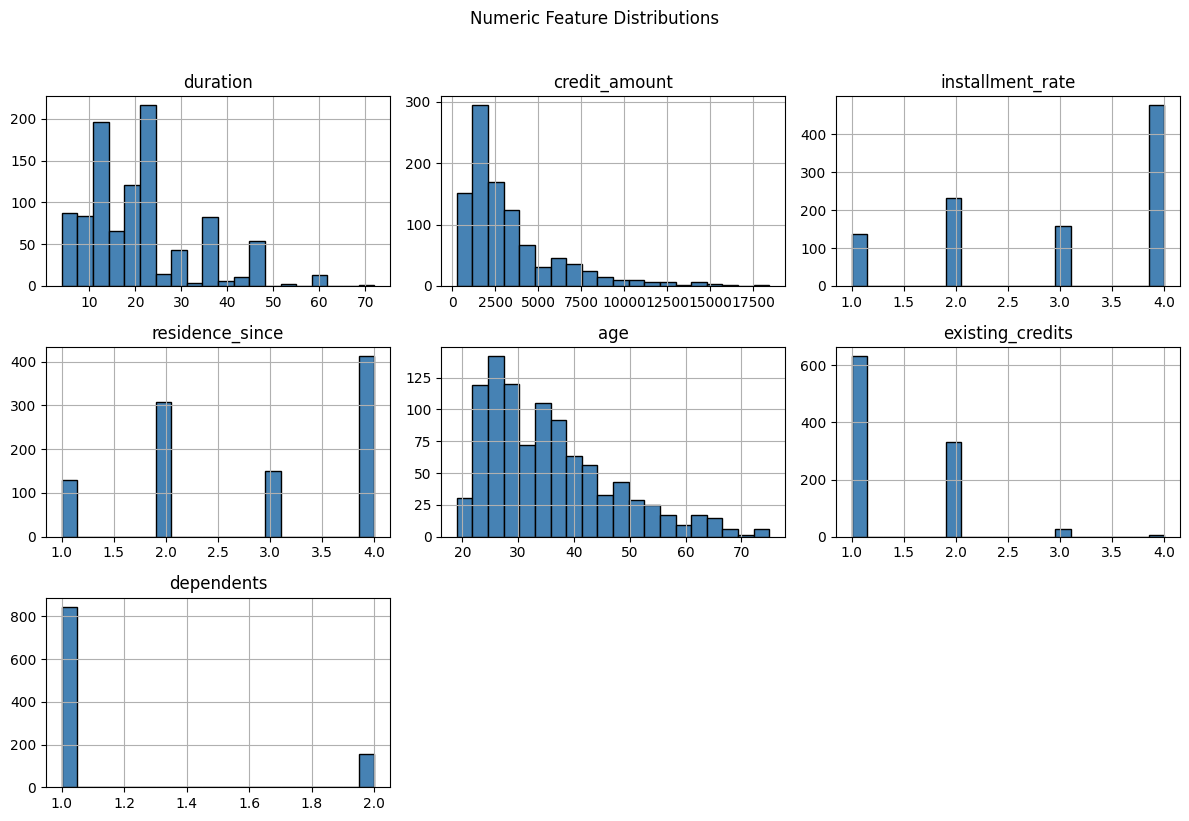

In [4]:
numeric_cols = df.select_dtypes(include='number').columns.drop('target')

df[numeric_cols].hist(bins=20, figsize=(12, 8), color='steelblue', edgecolor='black')
plt.suptitle('Numeric Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

IndexError: index 6 is out of bounds for axis 0 with size 6

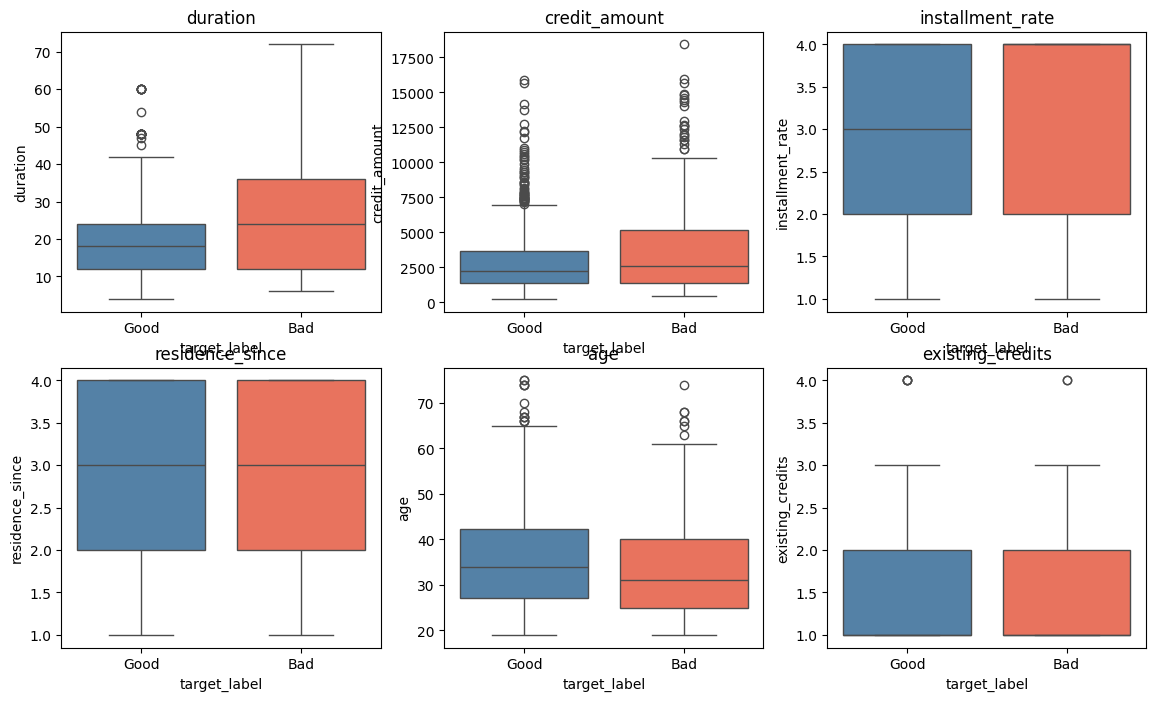

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

df['target_label'] = df['target'].map({1: 'Good', 2: 'Bad'})

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='target_label', y=col, data=df, ax=axes[i],
                hue='target_label',
                palette={'Good': 'steelblue', 'Bad': 'tomato'},
                legend=False)
    axes[i].set_title(col)

plt.suptitle('Numeric Features vs Target', y=1.02)
plt.tight_layout()
plt.show()

/var/folders/lc/r7kmct2j6sn8wq0zv7q0gwlw0000gn/T/ipykernel_54400/1697116645.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.drop('target_label')


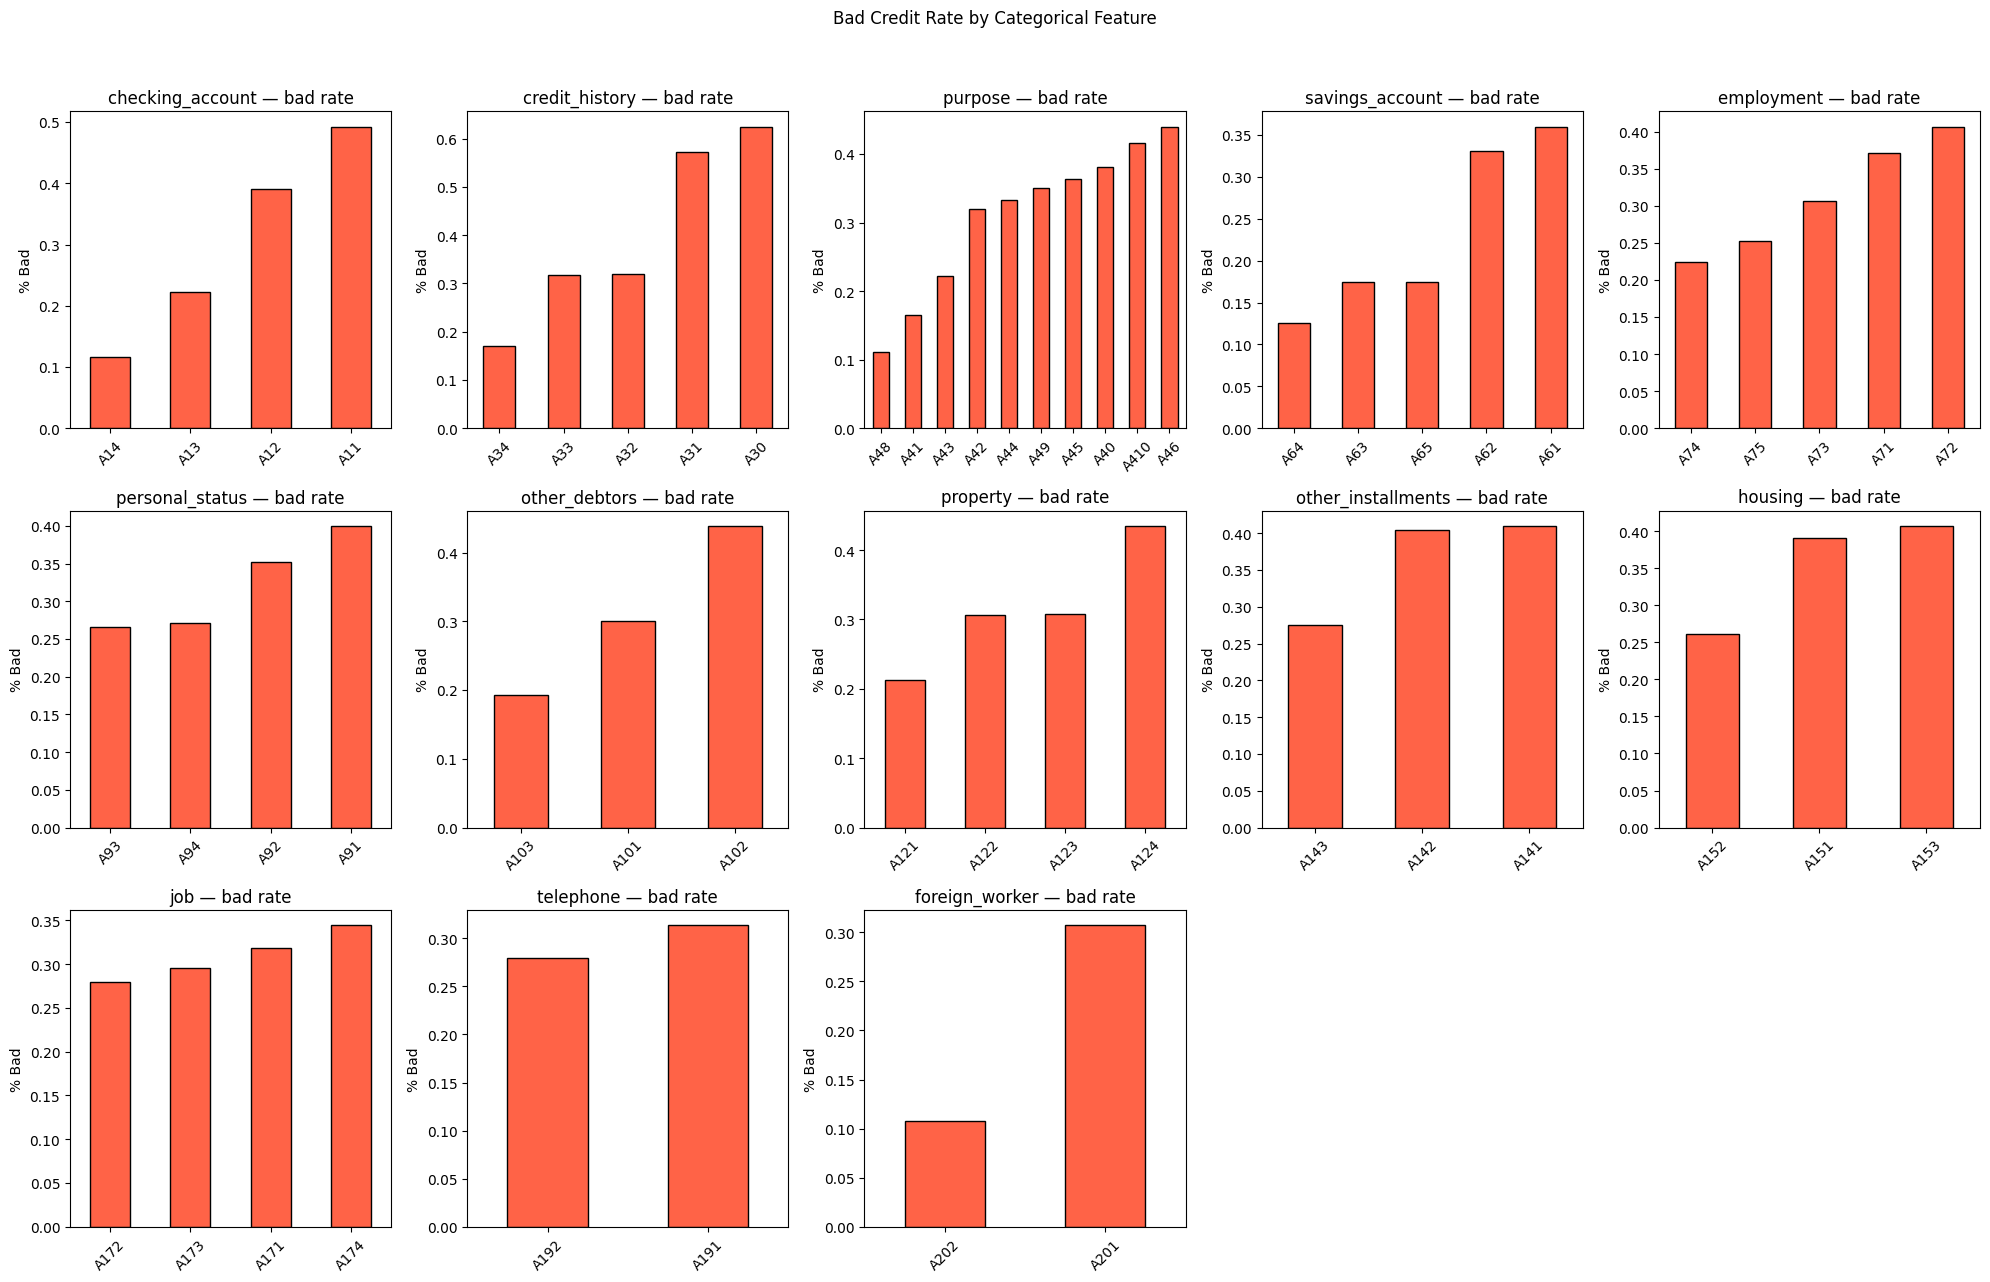

In [8]:
cat_cols = df.select_dtypes(include='object').columns.drop('target_label')

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    bad_rate = df.groupby(col)['target'].apply(lambda x: (x == 2).mean())
    bad_rate.sort_values().plot(kind='bar', ax=axes[i], color='tomato', edgecolor='black')
    axes[i].set_title(f'{col} — bad rate')
    axes[i].set_ylabel('% Bad')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Bad Credit Rate by Categorical Feature', y=1.02)
plt.tight_layout()
plt.show()